# RPG & SASRec hyperparameter analysis

Each section states its **conclusion first** (a *Takeaway*), then the supporting
figures and a table of NDCG values. Four datasets: Sports, Beauty, Toys, CDs.

- **§1 Semantic-ID length `m`** — the Claim-2 scaling experiment (re-decoded checkpoints).
- **§2 Decode parameters** `b`/`k`/`q` — Figure-6 sweeps (re-decoded, no retraining).
- **§3 RPG training** — learning rate × temperature (full retrain per cell).
- **§4 SASRec baseline** — learning rate × dropout × depth (full retrain per cell).

Selection rule for training grids: pick the config that wins on **validation**,
report its **test** score.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator

BASE = Path.cwd()
ROOT = BASE if (BASE / "scripts").exists() else BASE.parent
SEARCH = [ROOT, ROOT / "results"]
FIG_DIR = ROOT / "results" / "figures"
TAB_DIR = ROOT / "results" / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

WONG = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000"]
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True, "grid.alpha": 0.3})

DATASETS = ["sports_and_outdoors", "beauty", "toys_and_games", "cds_and_vinyl"]
LABELS = {"sports_and_outdoors": "Sports", "beauty": "Beauty",
          "toys_and_games": "Toys", "cds_and_vinyl": "CDs"}
TRAIN_DATASETS = ["sports_and_outdoors", "beauty", "toys_and_games"]
TITLE2SNAKE = {"Sports_and_Outdoors": "sports_and_outdoors", "Beauty": "beauty",
               "Toys_and_Games": "toys_and_games", "CDs_and_Vinyl": "cds_and_vinyl"}

M_VALUES = [4, 8, 16, 32, 64]
PAPER_BEST_M = {"sports_and_outdoors": 16, "beauty": 32, "toys_and_games": 16, "cds_and_vinyl": 64}
PAPER_BEST_NDCG10 = {"sports_and_outdoors": 0.0263, "beauty": 0.0464,
                     "toys_and_games": 0.0490, "cds_and_vinyl": 0.0415}

TUNED = {"sports_and_outdoors": (0.003, 0.03), "beauty": (0.01, 0.03),
         "toys_and_games": (0.003, 0.03), "cds_and_vinyl": (0.001, 0.03)}
SASREC_RELEASED = {"lr": 0.001, "dropout": 0.5, "n_blocks": 2}


def find_csv(name):
    for d in SEARCH:
        if (d / name).exists():
            return d / name
    return None


def load_decode(name):
    cols = ["dataset", "num_beams", "n_edges", "propagation_steps", "metric", "mean", "std", "n_seeds"]
    p = find_csv(name)
    return pd.read_csv(p) if p is not None else pd.DataFrame(columns=cols)


def load_train(name):
    p = find_csv(name)
    if p is None:
        return pd.DataFrame(columns=["dataset", "lr", "temperature", "metric", "mean", "std",
                                     "n_seeds", "val_ndcg10_mean", "val_ndcg10_std"])
    df = pd.read_csv(p)
    if "mean" not in df.columns and "value" in df.columns:
        df = df.rename(columns={"value": "mean"}).assign(std=0.0, n_seeds=1)
    if "val_ndcg10_mean" not in df.columns:
        df["val_ndcg10_mean"] = np.nan
    return df


def load_sasrec(name):
    p = find_csv(name)
    cols = ["dataset", "lr", "dropout", "n_blocks", "metric", "test_mean", "test_std",
            "n_seeds", "val_ndcg20_mean", "val_ndcg20_std"]
    return pd.read_csv(p) if p is not None else pd.DataFrame(columns=cols)


def load_msweep(name="redecode_compare.csv"):
    p = find_csv(name)
    if p is None:
        return pd.DataFrame()
    df = pd.read_csv(p)
    df["dataset"] = df["dataset"].map(TITLE2SNAKE).fillna(df["dataset"])
    return df


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", bbox_inches="tight")


def best_by_val_rpg(df, dataset, metric="ndcg@10"):
    sub = df[(df["dataset"] == dataset) & (df["metric"] == metric)].copy()
    sub["val_ndcg10_mean"] = pd.to_numeric(sub["val_ndcg10_mean"], errors="coerce")
    sub = sub[sub["val_ndcg10_mean"].notna()]
    return None if sub.empty else sub.loc[sub["val_ndcg10_mean"].idxmax()]


def best_by_val_sasrec(df, dataset, metric="ndcg@10"):
    sub = df[(df["dataset"] == dataset) & (df["metric"] == metric)].copy()
    sub["val_ndcg20_mean"] = pd.to_numeric(sub["val_ndcg20_mean"], errors="coerce")
    sub = sub[sub["val_ndcg20_mean"].notna()]
    return None if sub.empty else sub.loc[sub["val_ndcg20_mean"].idxmax()]


fig6 = load_decode("fig6_grid.csv")
msweep = load_msweep()
train = load_train("train_grid.csv")
sasrec = load_sasrec("sasrec_train_grid.csv")
pd.Series({"fig6": len(fig6), "msweep": len(msweep), "train": len(train), "sasrec": len(sasrec)})

fig6      240
msweep     20
train     180
sasrec    198
dtype: int64

## 1. Semantic-ID length `m` (Claim 2)

**Takeaway.** Test NDCG@10 rises steeply with ID length `m`, reaches a per-dataset
optimum, then plateaus or declines — reproducing the paper's scaling behaviour. Our
optimum matches the paper exactly on Sports (m=16), Beauty (m=32) and CDs (m=64);
Toys peaks at m=32 but m=16 is statistically tied (0.0465 vs 0.0467), so it is
consistent with the paper's m=16. At the optimum our absolute NDCG@10 is within
~3–5% of the paper's reported values (table below); the small shortfall is the
expected single-pipeline reproduction gap.

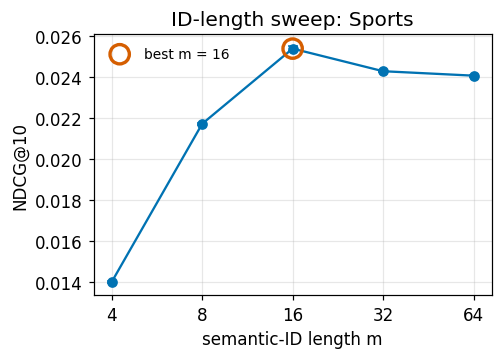

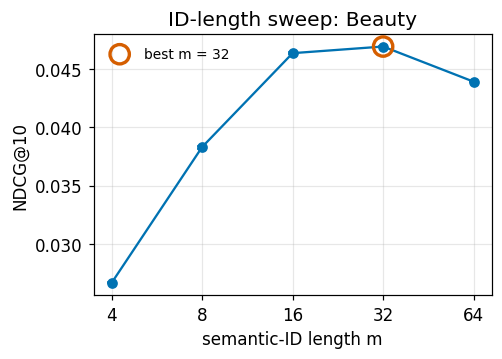

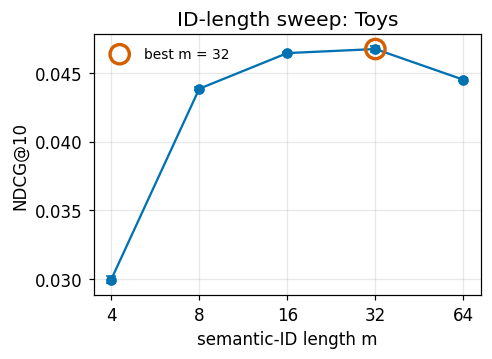

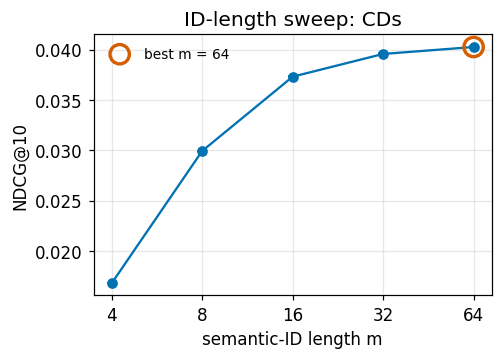

In [2]:
def m_sweep_figure(df, dataset, metric="ndcg@10"):
    sub = df[df["dataset"] == dataset].sort_values("m")
    if sub.empty:
        print("no m-sweep data for", dataset)
        return
    mcol, scol = f"repo_harness_mean_{metric}", f"repo_harness_std_{metric}"
    fig, ax = plt.subplots(figsize=(4.7, 3.4))
    ax.errorbar(sub["m"], sub[mcol], yerr=sub[scol].fillna(0), marker="o", color=WONG[0], capsize=3)
    best = sub.loc[sub[mcol].idxmax()]
    ax.scatter([best["m"]], [best[mcol]], s=160, facecolors="none", edgecolors=WONG[1],
               lw=2.2, zorder=5, label=f"best m = {int(best['m'])}")
    ax.set_xscale("log", base=2)
    ax.set_xticks(M_VALUES, M_VALUES)
    ax.set_xlabel("semantic-ID length m")
    ax.set_ylabel(metric.upper())
    ax.set_title(f"ID-length sweep: {LABELS[dataset]}")
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    save(fig, f"msweep_{dataset}")
    plt.show()


for ds in DATASETS:
    m_sweep_figure(msweep, ds)

In [3]:
def m_sweep_table(df, metric="ndcg@10"):
    mcol = f"repo_harness_mean_{metric}"
    rows = []
    for ds in DATASETS:
        sub = df[df["dataset"] == ds]
        if sub.empty:
            continue
        best = sub.loc[sub[mcol].idxmax()]
        ours = float(best[mcol])
        paper_v = PAPER_BEST_NDCG10.get(ds)
        rows.append({
            "dataset": LABELS[ds],
            "our_best_m": int(best["m"]),
            f"our_{metric}": round(ours, 4),
            "paper_best_m": PAPER_BEST_M.get(ds),
            f"paper_{metric}": paper_v,
            "gap_%": None if paper_v is None else round(100 * (ours - paper_v) / paper_v, 1),
        })
    out = pd.DataFrame(rows)
    out.to_csv(TAB_DIR / "msweep_best.csv", index=False)
    return out


m_sweep_table(msweep)

,dataset,our_best_m,our_ndcg@10,paper_best_m,paper_ndcg@10,gap_%
0,Sports,16,0.0254,16,0.0263,-3.5
1,Beauty,32,0.0469,32,0.0464,1.1
2,Toys,32,0.0467,16,0.0490,-4.6
3,CDs,64,0.0403,64,0.0415,-3.0


## 2. Decode parameters: beam `b`, edges/node `k`, steps `q` (Figure 6)

**Takeaway.** Re-decoding a fixed best-`m` checkpoint while varying each decode
parameter (others held at the base `b=10, k=50, q=2`): edges/node `k` and
propagation steps `q` both rise from low values and saturate (`q` jumps off `q=0/1`
and plateaus by `q≈2`); beam width `b` rises gently and is comparatively flat in
this `b≤50` range. The curve *shapes* match the paper's Figure 6 on all four
datasets — the conclusion the figure supports — while absolute values differ after
the authors' post-publication bug fix.

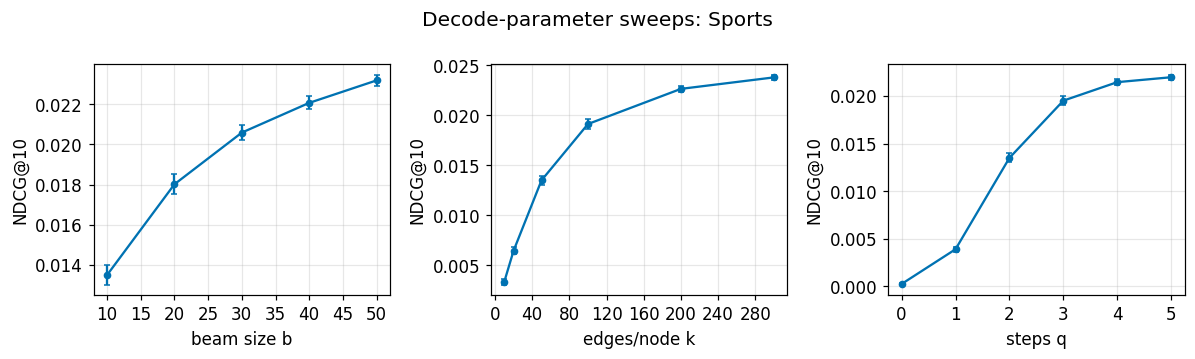

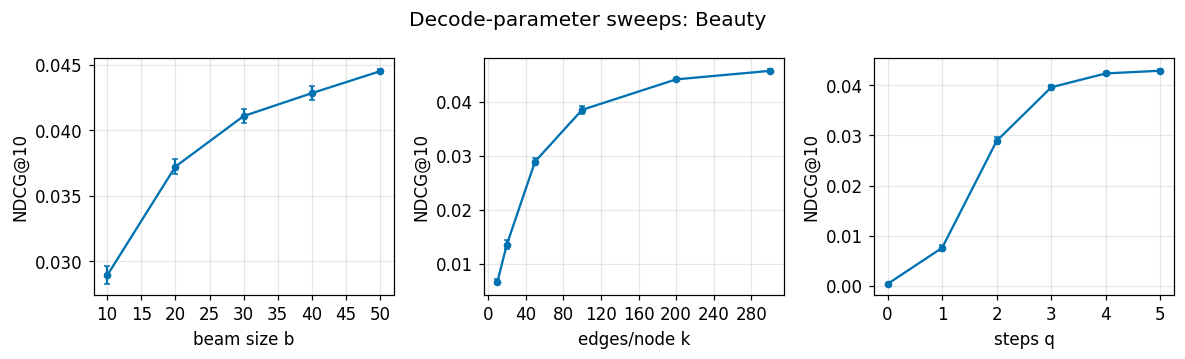

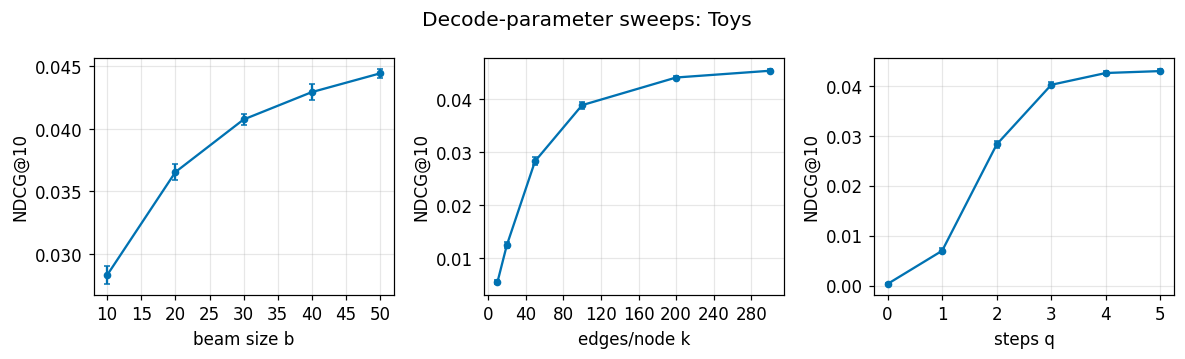

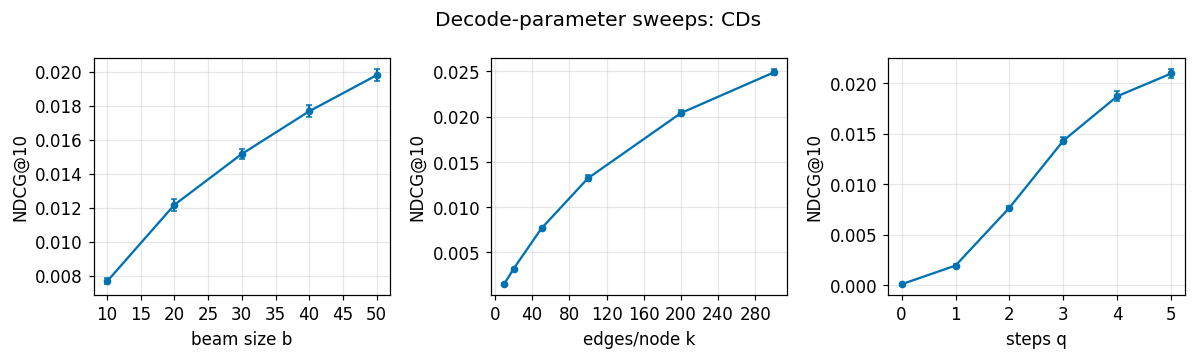

In [4]:
def decode_sweeps(df, dataset, metric="ndcg@10", base=(10, 50, 2)):
    b0, k0, q0 = base
    sub = df[(df["dataset"] == dataset) & (df["metric"] == metric)]
    if sub.empty:
        print("no decode data for", dataset)
        return
    panels = [("num_beams", {"n_edges": k0, "propagation_steps": q0}, "beam size b"),
              ("n_edges", {"num_beams": b0, "propagation_steps": q0}, "edges/node k"),
              ("propagation_steps", {"num_beams": b0, "n_edges": k0}, "steps q")]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))   # independent axes (no sharex/sharey)
    for ax, (x, hold, xlabel) in zip(axes, panels):
        d = sub
        for hk, hv in hold.items():
            d = d[d[hk] == hv]
        d = d.sort_values(x)
        if not d.empty:
            ax.errorbar(d[x], d["mean"], yerr=d["std"].fillna(0), marker="o", ms=4,
                        color=WONG[0], capsize=2)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(metric.upper())
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    fig.suptitle(f"Decode-parameter sweeps: {LABELS[dataset]}")
    fig.tight_layout()
    save(fig, f"decode_{dataset}")
    plt.show()


for ds in DATASETS:
    decode_sweeps(fig6, ds)

## 3. RPG training grid: learning rate × temperature

**Takeaway.** Learning rate dominates RPG test NDCG@10; temperature barely matters,
and the high-lr corner collapses (the model diverges). The val-selected optimum
(green, dashed) sits in the same low-lr / low-temperature region as the released
config (orange), and the test-score gap between them is ≤0.0015 everywhere — i.e.
within seed noise. Re-tuning does **not** beat the released RPG settings.

*(Heatmap colour is relative within each panel — datasets sit at very different
NDCG levels — so read the printed cell values for absolute test NDCG@10.)*

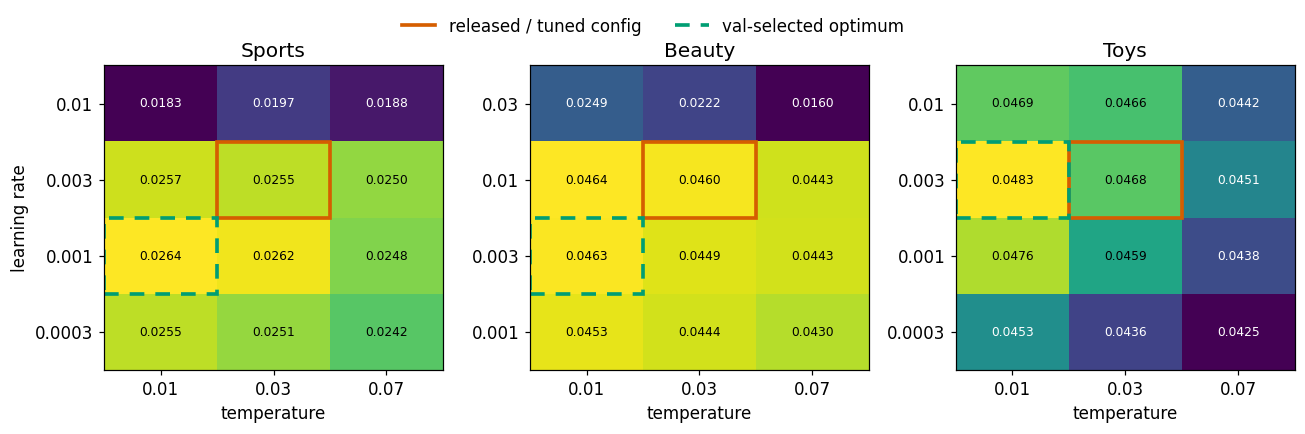

In [5]:
def heatmap_panel(ax, grid):
    arr = grid.values.astype(float)
    ax.imshow(arr, origin="lower", aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(grid.columns)), grid.columns)
    ax.set_yticks(range(len(grid.index)), grid.index)
    ax.grid(False)
    vmin, vmax = np.nanmin(arr), np.nanmax(arr)
    for yi in range(arr.shape[0]):
        for xi in range(arr.shape[1]):
            v = arr[yi, xi]
            if np.isfinite(v):
                norm = (v - vmin) / (vmax - vmin + 1e-12)
                ax.text(xi, yi, f"{v:.4f}", ha="center", va="center",
                        color="black" if norm > 0.55 else "white", fontsize=8)


def outline(ax, grid, col_val, row_val, color, dashed=False):
    cols, idx = list(grid.columns), list(grid.index)
    if row_val in idx and col_val in cols:
        ax.add_patch(plt.Rectangle((cols.index(col_val) - 0.5, idx.index(row_val) - 0.5), 1, 1,
                                   fill=False, edgecolor=color, lw=2.4,
                                   ls=(0, (4, 3)) if dashed else "-"))


def rpg_heatmaps(df, metric="ndcg@10"):
    dss = [d for d in TRAIN_DATASETS if not df[df["dataset"] == d].empty]
    fig, axes = plt.subplots(1, len(dss), figsize=(4.0 * len(dss), 3.8))
    axes = np.atleast_1d(axes)
    for ax, ds in zip(axes, dss):
        sub = df[(df["dataset"] == ds) & (df["metric"] == metric)]
        grid = sub.pivot_table(index="lr", columns="temperature", values="mean")
        heatmap_panel(ax, grid)
        lr_t, te_t = TUNED[ds]
        outline(ax, grid, te_t, lr_t, WONG[1])
        best = best_by_val_rpg(df, ds, metric)
        if best is not None:
            outline(ax, grid, best["temperature"], best["lr"], WONG[2], dashed=True)
        ax.set_xlabel("temperature")
        ax.set_title(LABELS[ds])
    axes[0].set_ylabel("learning rate")
    handles = [Line2D([0], [0], color=WONG[1], lw=2.4, label="released / tuned config"),
               Line2D([0], [0], color=WONG[2], lw=2.4, ls=(0, (4, 3)), label="val-selected optimum")]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))
    fig.tight_layout()
    save(fig, "rpg_lrtemp_heatmaps")
    plt.show()


rpg_heatmaps(train)

In [6]:
def rpg_scorecard(df, metric="ndcg@10"):
    rows = []
    for ds in TRAIN_DATASETS:
        sub = df[(df["dataset"] == ds) & (df["metric"] == metric)]
        if sub.empty:
            continue
        best = best_by_val_rpg(df, ds, metric)
        lr_t, te_t = TUNED[ds]
        tuned = sub[(sub["lr"] == lr_t) & (sub["temperature"] == te_t)]
        tm = float(tuned["mean"].iloc[0]) if not tuned.empty else np.nan
        bm = float(best["mean"]) if best is not None else np.nan
        rows.append({"dataset": LABELS[ds],
                     "released_cfg": f"lr={lr_t}, t={te_t}",
                     "released_test": round(tm, 4),
                     "selected_cfg": "" if best is None else f"lr={best['lr']}, t={best['temperature']}",
                     "selected_test": round(bm, 4),
                     "delta": round(bm - tm, 4)})
    out = pd.DataFrame(rows)
    out.to_csv(TAB_DIR / "rpg_train_best.csv", index=False)
    return out


rpg_scorecard(train)

,dataset,released_cfg,released_test,selected_cfg,selected_test,delta
0,Sports,"lr=0.003, t=0.03",0.0255,"lr=0.001, t=0.01",0.0264,0.0008
1,Beauty,"lr=0.01, t=0.03",0.0460,"lr=0.003, t=0.01",0.0463,0.0003
2,Toys,"lr=0.003, t=0.03",0.0468,"lr=0.003, t=0.01",0.0483,0.0015


## 4. SASRec baseline: learning rate × dropout, and depth

**Takeaway.** SASRec is most sensitive to learning rate: the val-selected optimum
(green, dashed) sits at **lr=3e-4**, one step below the released **lr=1e-3**
(orange), and this lower rate lifts test NDCG@10 by ~10% (Beauty 0.0294→0.0324,
Toys 0.0381→0.0420, Sports 0.0180→0.0194) — so the released SASRec learning rate is
sub-optimal on these datasets. Dropout matters less (best stays near the released
0.5, except Beauty prefers 0.2). Adding self-attention blocks beyond 2 gives no
consistent gain — depth is not the bottleneck here.

*(Heatmap colour is relative within each panel; read cell values for absolute test NDCG@10.)*

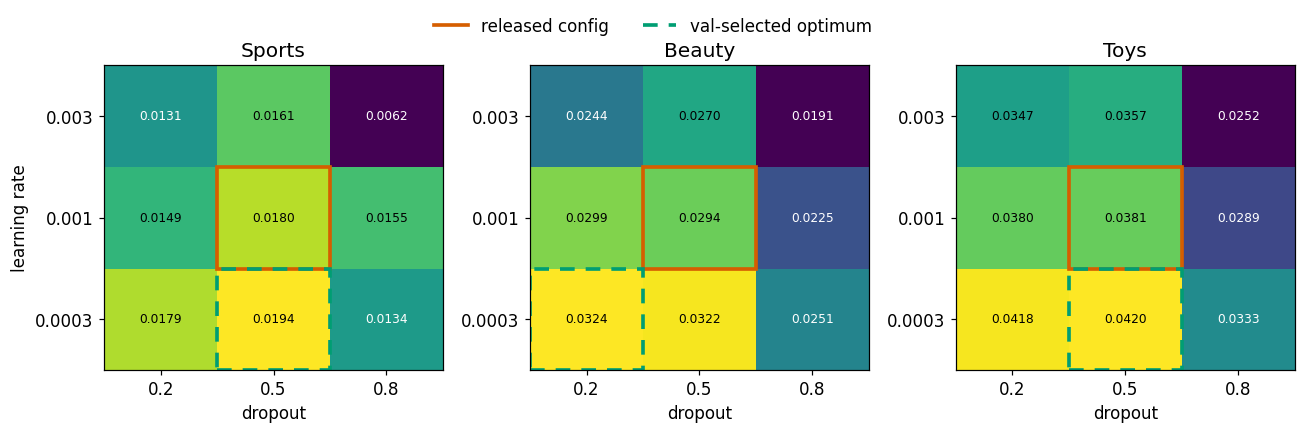

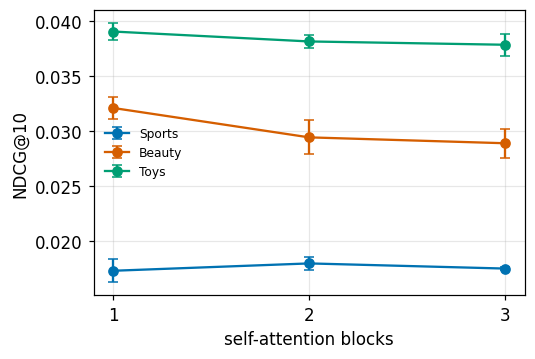

In [7]:
def sasrec_heatmaps(df, metric="ndcg@10", blocks=2):
    dss = [d for d in TRAIN_DATASETS if not df[df["dataset"] == d].empty]
    fig, axes = plt.subplots(1, len(dss), figsize=(4.0 * len(dss), 3.8))
    axes = np.atleast_1d(axes)
    for ax, ds in zip(axes, dss):
        sub = df[(df["dataset"] == ds) & (df["metric"] == metric) & (df["n_blocks"] == blocks)]
        grid = sub.pivot_table(index="lr", columns="dropout", values="test_mean")
        heatmap_panel(ax, grid)
        outline(ax, grid, SASREC_RELEASED["dropout"], SASREC_RELEASED["lr"], WONG[1])
        best = best_by_val_sasrec(df, ds, metric)
        if best is not None and best["n_blocks"] == blocks:
            outline(ax, grid, best["dropout"], best["lr"], WONG[2], dashed=True)
        ax.set_xlabel("dropout")
        ax.set_title(LABELS[ds])
    axes[0].set_ylabel("learning rate")
    handles = [Line2D([0], [0], color=WONG[1], lw=2.4, label="released config"),
               Line2D([0], [0], color=WONG[2], lw=2.4, ls=(0, (4, 3)), label="val-selected optimum")]
    fig.legend(handles=handles, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.05))
    fig.tight_layout()
    save(fig, "sasrec_lrdrop_heatmaps")
    plt.show()


def sasrec_block_sweep(df, metric="ndcg@10"):
    present = [d for d in TRAIN_DATASETS if not df[df["dataset"] == d].empty]
    if not present:
        print("no sasrec data")
        return
    fig, ax = plt.subplots(figsize=(5.0, 3.4))
    for i, ds in enumerate(present):
        sub = df[(df["dataset"] == ds) & (df["metric"] == metric)
                 & (df["lr"] == SASREC_RELEASED["lr"]) & (df["dropout"] == SASREC_RELEASED["dropout"])
                 ].sort_values("n_blocks")
        if not sub.empty:
            ax.errorbar(sub["n_blocks"], sub["test_mean"], yerr=sub["test_std"].fillna(0),
                        marker="o", capsize=3, color=WONG[i], label=LABELS[ds])
    ax.set_xlabel("self-attention blocks")
    ax.set_ylabel(metric.upper())
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    save(fig, "sasrec_blocks")
    plt.show()


sasrec_heatmaps(sasrec)
sasrec_block_sweep(sasrec)

In [8]:
def sasrec_scorecard(df, metric="ndcg@10"):
    rows = []
    for ds in TRAIN_DATASETS:
        sub = df[(df["dataset"] == ds) & (df["metric"] == metric)]
        if sub.empty:
            continue
        best = best_by_val_sasrec(df, ds, metric)
        rel = sub[(sub["lr"] == SASREC_RELEASED["lr"]) & (sub["dropout"] == SASREC_RELEASED["dropout"])
                  & (sub["n_blocks"] == SASREC_RELEASED["n_blocks"])]
        rm = float(rel["test_mean"].iloc[0]) if not rel.empty else np.nan
        bm = float(best["test_mean"]) if best is not None else np.nan
        rows.append({"dataset": LABELS[ds],
                     "released_cfg": f"lr={SASREC_RELEASED['lr']}, d={SASREC_RELEASED['dropout']}, b={SASREC_RELEASED['n_blocks']}",
                     "released_test": round(rm, 4),
                     "selected_cfg": "" if best is None else f"lr={best['lr']}, d={best['dropout']}, b={int(best['n_blocks'])}",
                     "selected_test": round(bm, 4),
                     "delta": round(bm - rm, 4)})
    out = pd.DataFrame(rows)
    out.to_csv(TAB_DIR / "sasrec_train_best.csv", index=False)
    return out


sasrec_scorecard(sasrec)

,dataset,released_cfg,released_test,selected_cfg,selected_test,delta
0,Sports,"lr=0.001, d=0.5, b=2",0.0180,"lr=0.0003, d=0.5, b=2",0.0194,0.0014
1,Beauty,"lr=0.001, d=0.5, b=2",0.0294,"lr=0.0003, d=0.2, b=2",0.0324,0.0030
2,Toys,"lr=0.001, d=0.5, b=2",0.0381,"lr=0.0003, d=0.5, b=2",0.0420,0.0039


## Figure 6 reproduction (README base, validation)

We reproduce the paper's Figure 6 by sweeping each decode parameter around each dataset's **README** configuration, on the **validation** split, matching the original paper, which tunes the inference-time hyperparameters on validation. Each panel varies one parameter ($b$, $k$, $q$) while holding the other two at the README base; data is sliced from the full joint decode grid (`decode_val_grid.csv`).

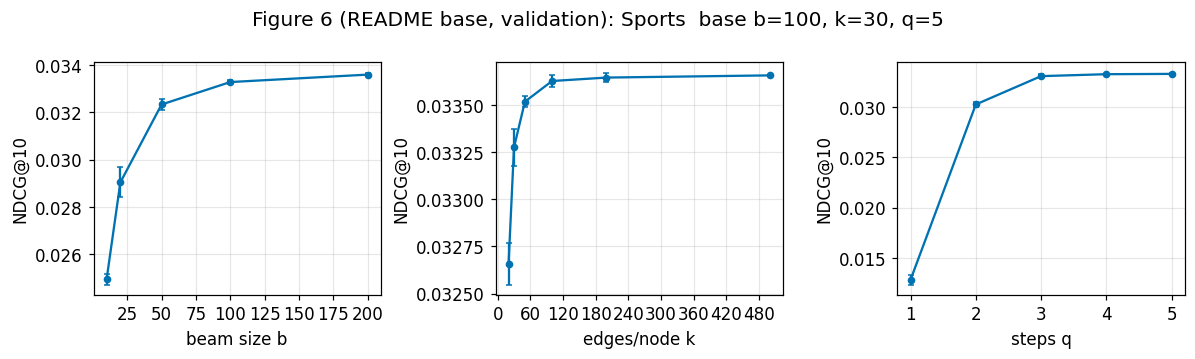

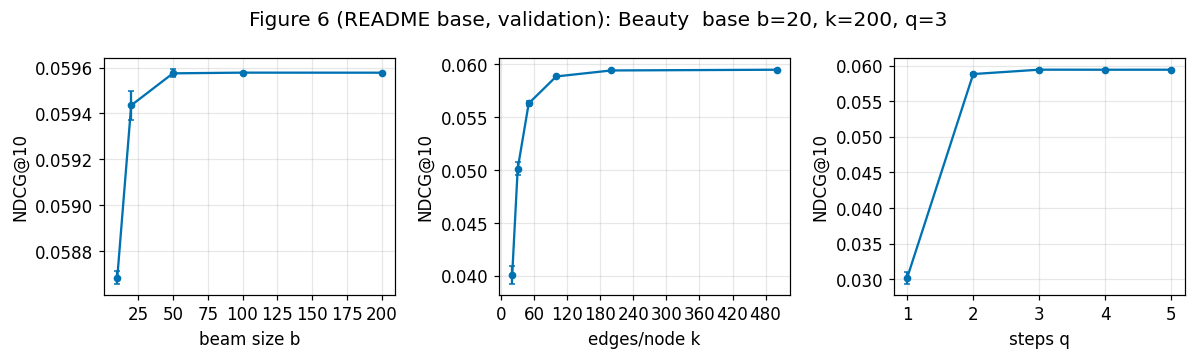

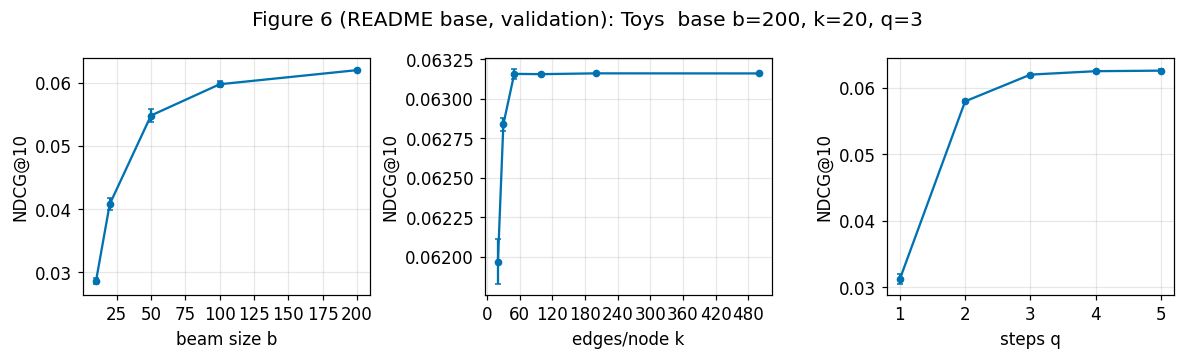

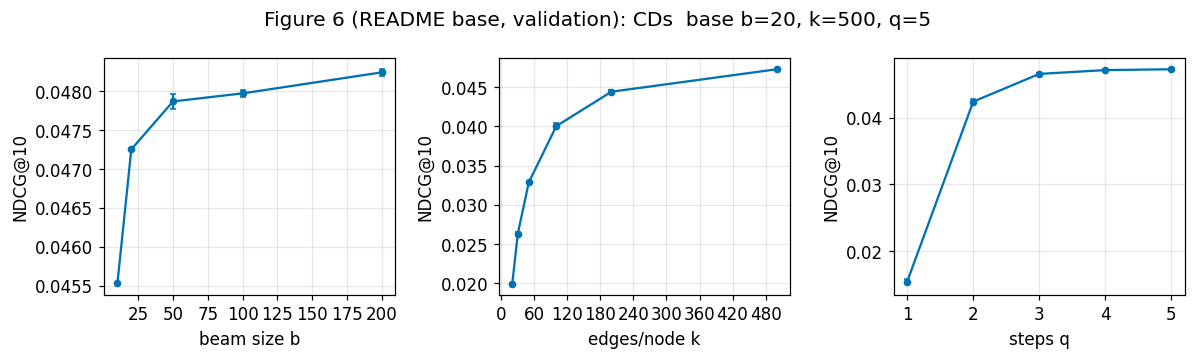

In [9]:
README_BASE = {"sports_and_outdoors": (100, 30, 5), "beauty": (20, 200, 3),
               "toys_and_games": (200, 20, 3), "cds_and_vinyl": (20, 500, 5)}
decode_val = load_decode("decode_val_grid.csv")


def fig6_readme(df, dataset, metric="ndcg@10"):
    if dataset not in README_BASE or df[df["dataset"] == dataset].empty:
        print("no decode_val data for", dataset)
        return
    b0, k0, q0 = README_BASE[dataset]
    sub = df[(df["dataset"] == dataset) & (df["metric"] == metric)]
    panels = [("num_beams", {"n_edges": k0, "propagation_steps": q0}, "beam size b"),
              ("n_edges", {"num_beams": b0, "propagation_steps": q0}, "edges/node k"),
              ("propagation_steps", {"num_beams": b0, "n_edges": k0}, "steps q")]
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.3))
    for ax, (x, hold, xlabel) in zip(axes, panels):
        d = sub
        for hk, hv in hold.items():
            d = d[d[hk] == hv]
        d = d.sort_values(x)
        if not d.empty:
            ax.errorbar(d[x], d["mean"], yerr=d["std"].fillna(0), marker="o", ms=4,
                        color=WONG[0], capsize=2)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(metric.upper())
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    fig.suptitle(f"Figure 6 (README base, validation): {LABELS[dataset]}  "
                 f"base b={b0}, k={k0}, q={q0}")
    fig.tight_layout()
    save(fig, f"fig6_readme_{dataset}")
    plt.show()


for ds in DATASETS:
    fig6_readme(decode_val, ds)